### Topics:
1. Probabilty
2. Permutations and Combinations
3. Confidence Intervals
   1. p value
4. Hypothesis Testing

In [ ]:
import numpy as np

data=[11,10,12,14,12,15,14,13,15,102,12,14,17,19,107,10,13,12,14,12,108,12,11,14,13,15,10,15,12,10,14,13,15,10]

# Finding outliers using Z score method
# so we know anythig outside of SD 3 may be outlier
mean = np.mean(data)
std_dev = np.std(data)
cutoff = std_dev * 3

lower, upper = mean - cutoff, mean + cutoff
outlier = [x for x in data if x < lower or x > upper]
outlier

[102, 107, 108]

In [14]:
# Finding outliers using IQR method
# data.sort()
q1, q3 = np.percentile(data, [25, 75])
iqr = q3 - q1
lower_boundary = q1 - 1.5*iqr
upper_boundary = q3 + 1.5*iqr
[x for x in data if x < lower_boundary or x > upper_boundary]

[102, 107, 108]

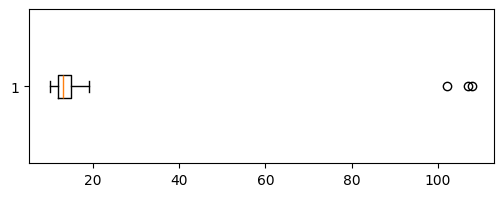

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 2))
plt.boxplot(data, vert=False)
plt.show()

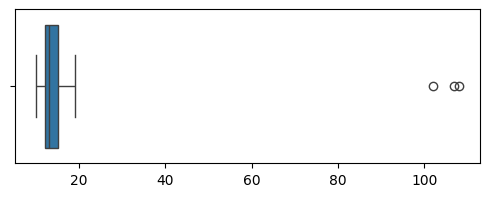

In [13]:
import seaborn as sns
plt.figure(figsize=(6, 2))
sns.boxplot(data, orient='h')
plt.show()

### 1. Probability
Probability is a number that tells you how likely something is to happen.

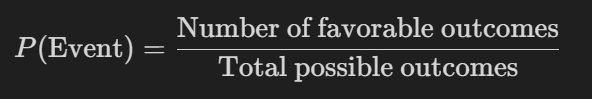

If you roll a die, what is the probability of getting a 4?
- favorable outcomes = 1
- total outcomes = 6

$P(4) = \frac{1}{6}$

${coin toss} → P(Heads) = \frac{1}{2}$

**Various Rules in Probability**
1. Probability Values Rule: $0 ≤ P(event) ≤1$
2. Total Probability Rule: $P(1) + P(2) + P(3) + P(4) + P(5) + P(6) = 1$
3. Complement Rule: ${P(A')} = 1 − P(A)$
4. Addition Rule (OR Rule)
   1. If A and B cannot happen together (mutually exclusive): $P(A∪B) = P(A) + P(B)$
   2. If A and B can happen together (general case): P(A∪B) = $P(A) + P(B) − P(A∩B)$
5. Multiplication Rule (AND Rule)
   1. If A and B are independent: $P(A∩B) = P(A) × P(B)$
   2. If A and B are not independent: $P(A∩B) = P(A) × P(B∣A)$
      - Where $P(B|A)$ = probability of B given A has happened.
6. Conditional Probability Rule: $P(B∣A) = \frac{P(A∩B)}{P(A)}$
   - probability of B happening after A has already happened.
7. Law of Total Probability: If an outcome depends on multiple ways something can happen
   - ${P(A)} = \sum{\frac{P(A | B_i)}{P(B_i)}}$
   - Used in classification, Bayes theorem, etc.
8. Bayes’ Rule: $P(A ∣ B) = \frac{P(B ∣ A) \cdot P(A)}{P(B)}$

--------------------------

**Mutual Exclusive Events**​
Two events are mutually exclusive if they cannot occur at the same time. ex. rolling a dice will give only one outcome at a time. We cannot get {2, 3} both in a single role

ex. Probability of coin landing on head or tails.<br>
P(heads or tails) = P(head) + P(tails) = 1/2 + 1/2 =1

ex. Roll a dice.<br>
P(1 or 3 or 6) = 1/6 + 1/6 + 1/6 = 0.5

**Non Mutual Exclusive Events**​
Two or more events can occur at a same time. ex. Pulling a card from a deck can yeild {Queen, red}, {Queen, black}

ex. Pick a card randomly, what is the probabilty that a card is queen or heart
P(queen) = 4/52<br>
P(heart) = 13/52<br>
P(queen and heart) = 1/52<br>
P(queen or heart) = 4/52 + 13/52 - 1/52 = 16/52<br>

**Independent Events**
Each and every events are independent and does not impact next outcome. ex. roll a dice once, we get 1. roll the dice again, we get 2 so the previous outcome does not impact next outcome. P(A∩B) = P(A) × P(B)

**Dependent Events**
Current event impacts the outcome of next event. ex. A bag filled with 3 red marbles and 2 gree marbles.

red marble = 3<br>
green marble = 2<br>
P(red) = 3/5<br>
In next step, there will be only 2 red marbles and 2 gree marbles present in bag<br>
P(green) = 2/4

$P(A∩B) = P(A) × P(B∣A)$<br>

Q1. Probability of getting 4 and then 5 while rolling a dice.<br>
Ans. $P(4 ∩ 5) = P(4) × P(5) = \frac{1}{6} \cdot \frac{1}{6} = \frac{1}{36}$

Q2. What is the probability of drawing a queen and then aces from a deck of card?<br>
Ans. $P(Queen ∩ aces) = P(queen) × P(aces ∣ queen)$  #Probability of aces given that the queen is already fetched<br>
$P(Queen ∩ aces) = \frac{4}{52} \cdot \frac{4}{51}$


### Permutations and Combinations

**Permutation:** Permutation = arranging items, When the order matters, use permutation.<br>
ex. How many ways can 3 people A,B,C can stand in a line?<br>
ABC, ACB, BAC, BCA, CAB, CBA : Total 6 ways

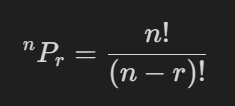

Where:<br>
- n is all the possible items
- r is required items

**Use Cases:**
- Arranging ordered sequences (NLP, time‑series tokens)
- Hyperparameter tuning where order matters
- Permutation tests (statistical significance testing)
- Feature importance via permutation importance
- Combinatorial optimization problems (TSP, scheduling, routing)
- Bootstrapping with ordered samples
- Generating all possible ordered outcomes


**Combination:** Combination = selecting items. When the order does NOT matter, use combination.<br>
How many ways to choose 3 students from a group of 10 for a project team?<br>
Team ABC is the same as CAB or BCA — order does NOT matter.

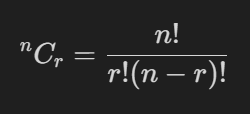


**Use Cases**
- Feature selection (choosing subsets of features)
- Grid search combinations of hyperparameters
- Sampling without replacement
- A/B and multivariate experiment design
- Probability calculations in statistics
- Model subset selection in machine learning
- Combinations of classes, labels, or items


### Some pre requisites

| Concept                         | Meaning                               |
|---------------------------------|---------------------------------------|
| Hypothesis                      | Claim we test                         |
| Null ${(H_o)}$                  | No effect                             |
| Alternative ${(H_1)}$           | Effect exists                         |
| Significance level ${(\alpha)}$ | Cutoff (usually 0.05)                 | 
| p‑value                         | Probability of your result assuming H₀|
| Decision                        | Reject H₀ if p < α                    | 
| CI                              | Range of likely true value            |

**Summary**
- **Hypothesis:** a claim
- **H₀:** nothing is happening
- **H₁:** something is happening
- **α:** decision cutoff (usually 0.05)
- **p‑value:** how surprising your result is IF H₀ were true
- **Reject H₀** when p < α
- **Confidence interval:** range of likely values (if significant value is 0.05 or 5% then CI is 1 - 0.05 0r 95%)

95% area under curve is our CI

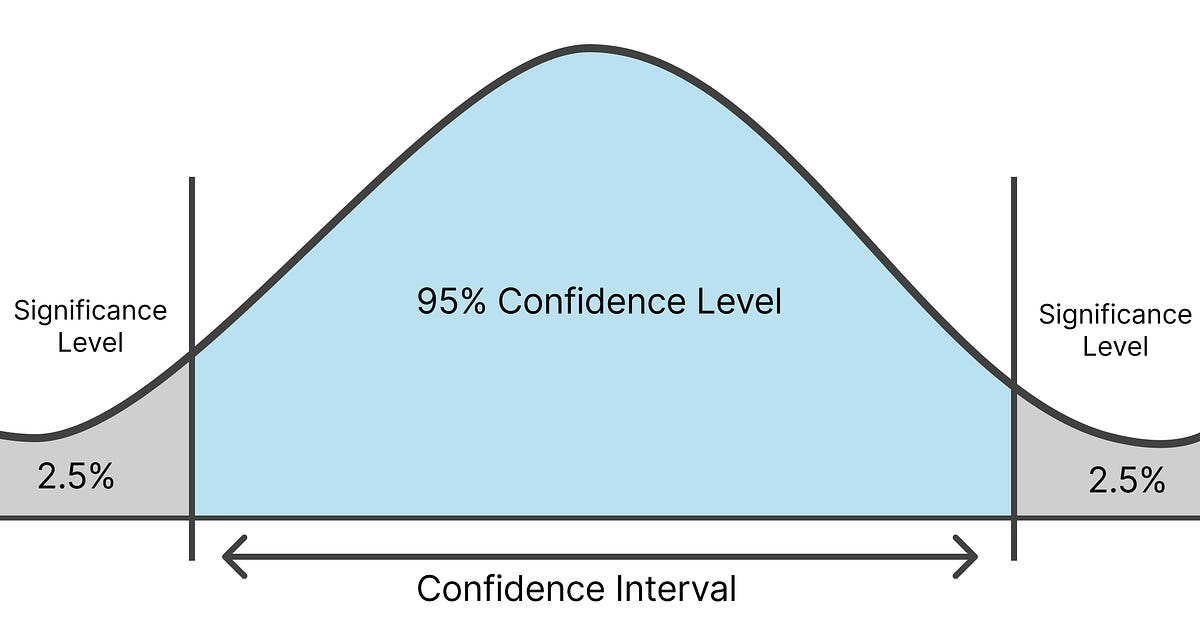

**example**
You test whether a medicine works.<br>
- ${H_o}$: medicine has no effect
- ${H_1}$: medicine works
- You run an experiment and get ${p}$ = 0.02
- Your ${\alpha}$ = 0.05

Since 0.02 < 0.05, you reject ${(H_o)}$.

**Meaning:** The result is unlikely under **no effect** → so the medicine probably works.

**example 2**<br>
Test whether a coin is fair coin or not by performing 100 tosses<br>
If we get 50 times head then we can say coin is fair coin<br>

- ${H_o}$: coin is fair
- ${H_1}$: coin is unfair
- Experiment (z test, t test anything): get some value
- reject or accept